# Análise de Séries Temporais — Jogadores Semanais de Counter-Strike 2

**Enunciado:** *"Apresentar uma análise de dados real"*

---

## Sumário

1. **Introdução** — descrição da base, importação e filtro 2016–2025
2. **Análise exploratória** — gráfico da série, descritivas, ACF/PACF, decomposição STL
3. **Estacionariedade** — testes ADF & KPSS, diferenciação
4. **Detecção de outliers** — `tsoutliers`
5. **Modelagem** — leitura dos gráficos ACF/PACF e `auto.arima`
6. **Diagnóstico dos resíduos** — ACF, Ljung-Box, normalidade, homocedasticidade
7. **Previsão** — h passos à frente com intervalos de confiança
8. **Validação** — janela treino/teste e métricas de erro


---

## Etapa 0: Funções auxiliares

Carregamos aqui as funções de apoio fornecidas em aula — médias móveis, análise de amplitude, sazonalidade, etc. Elas serão invocadas ao longo da análise.


In [1]:
# Funções fornecidas em aula ------------------------------------------------

media.amplitude <- function(x, k) {
  N <- length(x)
  x.m <- vapply(1:(N-k), function(i) mean(x[i:(i+k)]),  numeric(1))
  x.r <- vapply(1:(N-k), function(i) diff(range(x[i:(i+k)])), numeric(1))
  plot(x.m, x.r, xlab = "médias", ylab = "amplitude")
  aa1 <- lm(x.r ~ x.m)
  print(summary(aa1))
  abline(aa1$coef[1], aa1$coef[2], col = 2)
}

media.moveis <- function(x, k) {
  x <- as.vector(x); N <- length(x)
  xstar <- rep(NA, N)
  for (i in (1+k):(N-k)) xstar[i] <- mean(x[(i-k):(i+k)], na.rm = TRUE)
  ts.plot(x, col = 'darkorange3')
  lines(xstar, col = 2, lwd = 1)
  invisible(xstar)
}

grafico.sazonalidade <- function(x, s) {
  x <- as.vector(x); N <- length(x)
  Mx <- max(x); mx <- min(x)
  valor <- N %/% s
  plot(1:s, x[1:s], ylim = c(mx, Mx), xlim = c(0, s+1), type = "l")
  for (i in 1:valor) {
    y <- rep(NA, s)
    y[1:s] <- x[((i-1)*s+1):(i*s)]
    lines(y, col = i)
  }
}

grafico.boxplot <- function(x, s) {
  x <- as.vector(x); N <- length(x)
  valor <- N %/% s
  apoioy <- rep(1:s, valor)
  boxplot(x[1:(s*valor)] ~ apoioy, xlab = 'Sazonalidade')
}


---

## Etapa 1: Introdução

A análise de séries temporais é um método estatístico apropriado para dados levantados ao longo de um determinado período de tempo, permitindo identificar padrões, tendências e sazonalidades.

A série escolhida para esta análise é o **número semanal de jogadores de Counter-Strike 2** (anteriormente conhecido como CS:GO — *Counter-Strike: Global Offensive*), um jogo de tiro multiplayer disponível na plataforma Steam. Os dados foram extraídos da base pública da Steam, que registra o número de jogadores ativos por dia.

Para uma análise mais focada e precisa, a série foi filtrada entre **1 de janeiro de 2016** e **31 de dezembro de 2025**, e os registros diários foram agregados em médias **semanais** (semanas iniciando às segundas-feiras).

### Pacotes utilizados


In [2]:
# Instalação dos pacotes (execute uma única vez se necessário)
# install.packages(c("dplyr", "lubridate", "tseries", "forecast", "lmtest"))

library(dplyr)
library(lubridate)
library(tseries)
library(forecast)
library(lmtest)



Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'lubridate'


The following objects are masked from 'package:base':

    date, intersect, setdiff, union


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Carregando pacotes exigidos: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric




### 1.1 Importação e preparação dos dados

O arquivo `counter_strike.csv` contém registros diários com as colunas `DateTime` (data) e `Players` (número de jogadores). A rotina abaixo:

1. Lê o CSV;
2. Converte `DateTime` para o tipo `Date`;
3. Agrega os valores diários em médias semanais (semana iniciando na segunda-feira);
4. Filtra o intervalo 2016–2025.


In [3]:
cs <- read.csv("counter_strike.csv", sep = ';')

cs_semanal <- cs |>
  dplyr::mutate(semana = floor_date(as.Date(DateTime),
                                     unit       = "week",
                                     week_start = 1)) |>
  dplyr::filter(semana >= as.Date("2016-01-01"),
                semana <= as.Date("2025-12-31")) |>
  dplyr::group_by(semana) |>
  dplyr::summarise(jogadores = mean(Players, na.rm = TRUE))

cat("Dimensões:", nrow(cs_semanal), "semanas\n")
head(cs_semanal)


Dimensões: 522 semanas


semana,jogadores
<date>,<dbl>
2016-01-04,628781.0
2016-01-11,597923.1
2016-01-18,615375.0
2016-01-25,613932.7
2016-02-01,610113.6
2016-02-08,620624.4


Com a base pronta, criamos o objeto `ts` com frequência 52 (semanas por ano), a partir de janeiro de 2016:


In [4]:
serie <- ts(cs_semanal$jogadores,
            start     = c(2016, 1),
            frequency = 52)

cat("Início:", start(serie), "| Fim:", end(serie),
    "| Observações:", length(serie), "\n")


Início: 2016 1 | Fim: 2026 2 | Observações: 522 


---

## Etapa 2: Análise exploratória

Antes de qualquer modelagem, vamos inspecionar a série visualmente e calcular algumas estatísticas descritivas para entender seu comportamento geral.

### 2.1 Gráfico da série


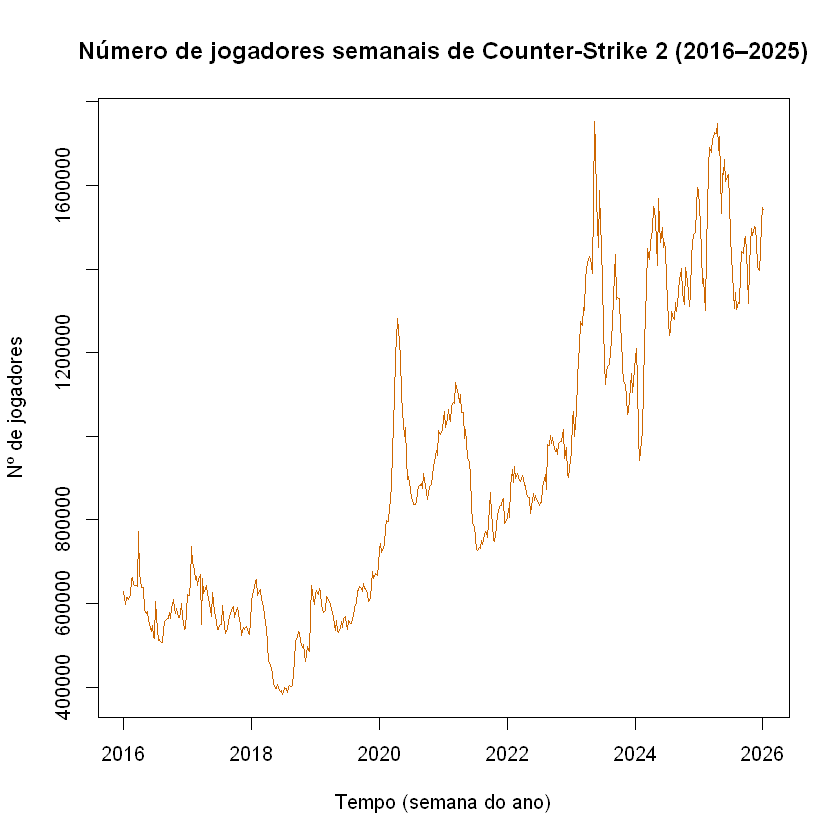

In [5]:
plot(serie,
     main = "Número de jogadores semanais de Counter-Strike 2 (2016–2025)",
     xlab = "Tempo (semana do ano)",
     ylab = "Nº de jogadores",
     col  = "darkorange3")


**Interpretação:** A série apresenta uma tendência crescente evidente ao longo de todo o período, com alguns picos acentuados que provavelmente correspondem a grandes eventos ou atualizações do jogo. Além disso, há um padrão que se repete anualmente — um indício de sazonalidade —, com picos no início do ano (período de férias/recesso) e vales ao longo dos demais meses.

### 2.2 Estatísticas descritivas


In [6]:
summary(serie)


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 382055  599685  849719  916332 1207915 1753420 

### 2.3 Decomposição STL

A função `stl` decompõe a série em três componentes aditivos:

$$X_t = T_t + S_t + R_t$$

onde $T_t$ é a tendência, $S_t$ é a sazonalidade e $R_t$ é o resíduo.


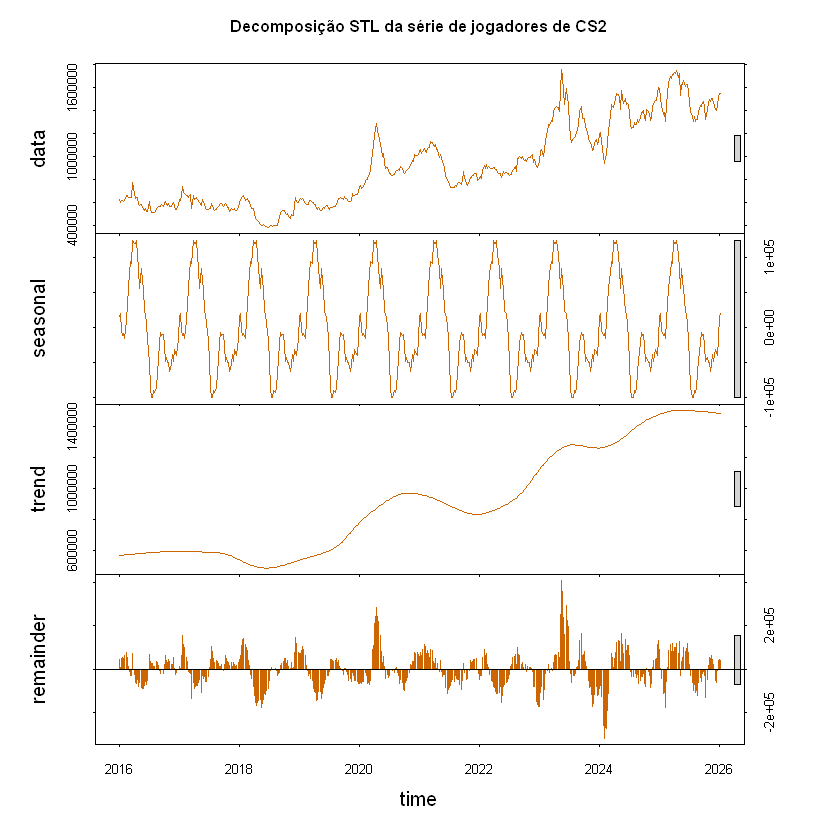

In [7]:
decomp <- stl(serie, s.window = "periodic")
plot(decomp,
     main = "Decomposição STL da série de jogadores de CS2",
     col  = "darkorange3")


**Interpretação:**

* **Tendência ($T_t$):** crescimento claro e contínuo ao longo de todo o período, com uma aceleração perceptível a partir de 2023, coincidindo com o lançamento do CS2.
* **Sazonalidade ($S_t$):** padrão anual bem definido, com maior número de jogadores no início de cada ano.
* **Resíduo ($R_t$):** oscila em torno de zero na maior parte do tempo, com picos notáveis em 2020 (pandemia) e 2023–2024 (lançamento do CS2).

### 2.4 Gráficos ACF e PACF

Os gráficos de autocorrelação (ACF) e autocorrelação parcial (PACF) ajudam a identificar a estrutura de dependência temporal da série.


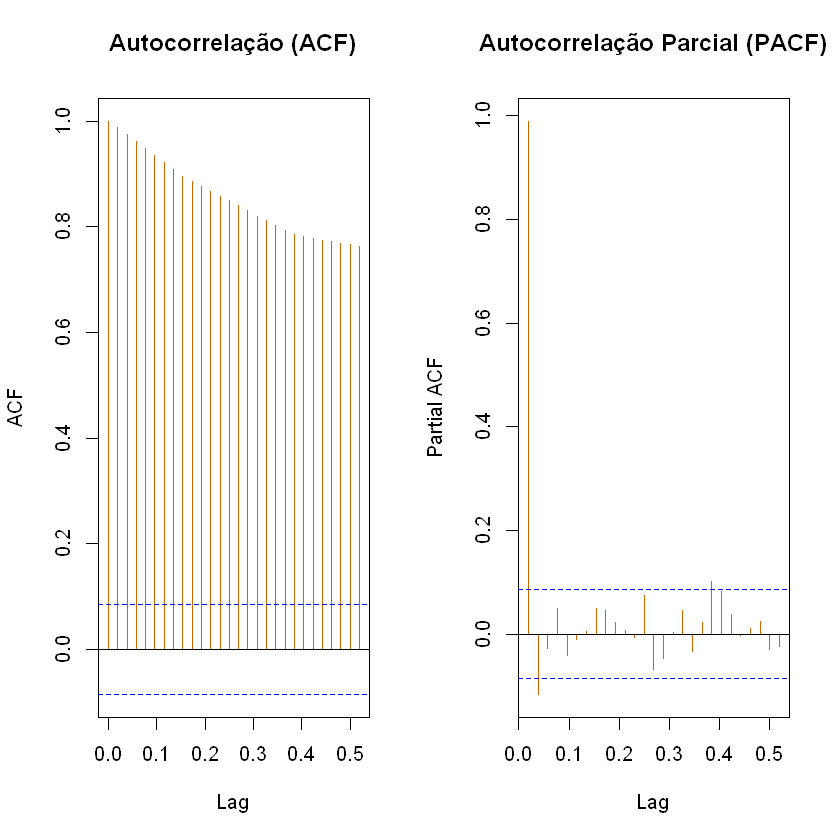

In [8]:
par(mfrow = c(1, 2))
acf (serie, main = "Autocorrelação (ACF)",         col = "darkorange3")
pacf(serie, main = "Autocorrelação Parcial (PACF)", col = "darkorange3")
par(mfrow = c(1, 1))


**Interpretação:**

* **ACF:** os lags decaem de forma muito lenta, sem entrar no intervalo de confiança por muitos lags. Esse comportamento é um indicativo claro de **tendência** — a série não é estacionária.
* **PACF:** o lag 1 é muito próximo de 1 e o lag 2 já está dentro do intervalo de confiança. Isso sugere que a componente autoregressiva pode ser de ordem $p = 1$.


---

## Etapa 3: Estacionariedade

Uma série estacionária possui média, variância e autocovariância constantes ao longo do tempo. Pelos gráficos anteriores, é claro que nossa série **não é estacionária** — a média cresce consistentemente. Vamos confirmar isso formalmente com dois testes:

| Teste | $H_0$ | $H_1$ |
|---|---|---|
| **ADF** (*Augmented Dickey-Fuller*) | Há raiz unitária (não-estacionária) | Não há raiz unitária (estacionária) |
| **KPSS** | Série estacionária | Série não-estacionária |

### 3.1 Testes na série original


In [9]:
adf.test(serie)   # H0: não-estacionária



	Augmented Dickey-Fuller Test

data:  serie
Dickey-Fuller = -3.5364, Lag order = 8, p-value = 0.03881
alternative hypothesis: stationary


In [10]:
kpss.test(serie)  # H0: estacionária


Warning message in kpss.test(serie):
"p-value smaller than printed p-value"



	KPSS Test for Level Stationarity

data:  serie
KPSS Level = 6.286, Truncation lag parameter = 6, p-value = 0.01


**Resultado:** O ADF apresenta $p\text{-valor} \approx 0{,}038$, sugerindo rejeição de $H_0$ (estacionariedade). Porém, o KPSS retorna $p\text{-valor} < 0{,}01$, rejeitando $H_0$ (e indicando não-estacionariedade). Os testes divergem, mas o comportamento visual e o KPSS indicam a necessidade de **diferenciar** a série.

### 3.2 Diferenciação de ordem 1

A diferenciação de ordem 1 remove a tendência linear ao calcular:

$$\nabla X_t = X_t - X_{t-1}$$


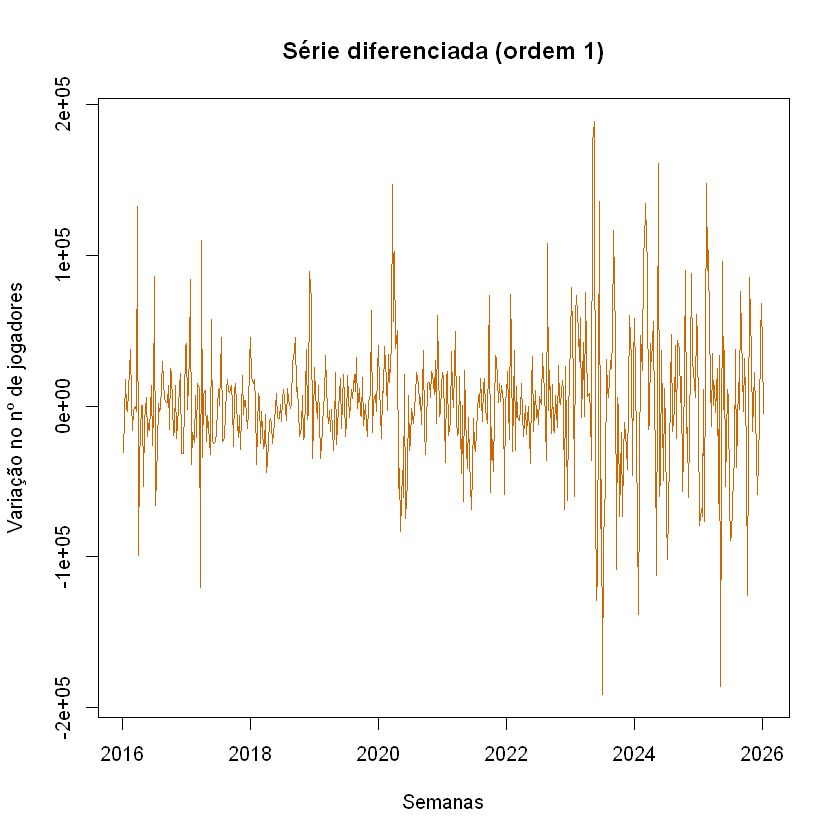

In [11]:
serie_diff <- diff(serie)

plot(serie_diff,
     main = "Série diferenciada (ordem 1)",
     xlab = "Semanas",
     ylab = "Variação no nº de jogadores",
     col  = "darkorange3")


A série diferenciada parece bem mais estacionária — a média oscila em torno de zero sem tendência clara. Vamos confirmar com os testes e os novos ACF/PACF.

### 3.3 Testes na série diferenciada


In [12]:
adf.test(serie_diff)


Warning message in adf.test(serie_diff):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  serie_diff
Dickey-Fuller = -8.6564, Lag order = 8, p-value = 0.01
alternative hypothesis: stationary


In [13]:
kpss.test(serie_diff)


Warning message in kpss.test(serie_diff):
"p-value greater than printed p-value"



	KPSS Test for Level Stationarity

data:  serie_diff
KPSS Level = 0.043643, Truncation lag parameter = 6, p-value = 0.1


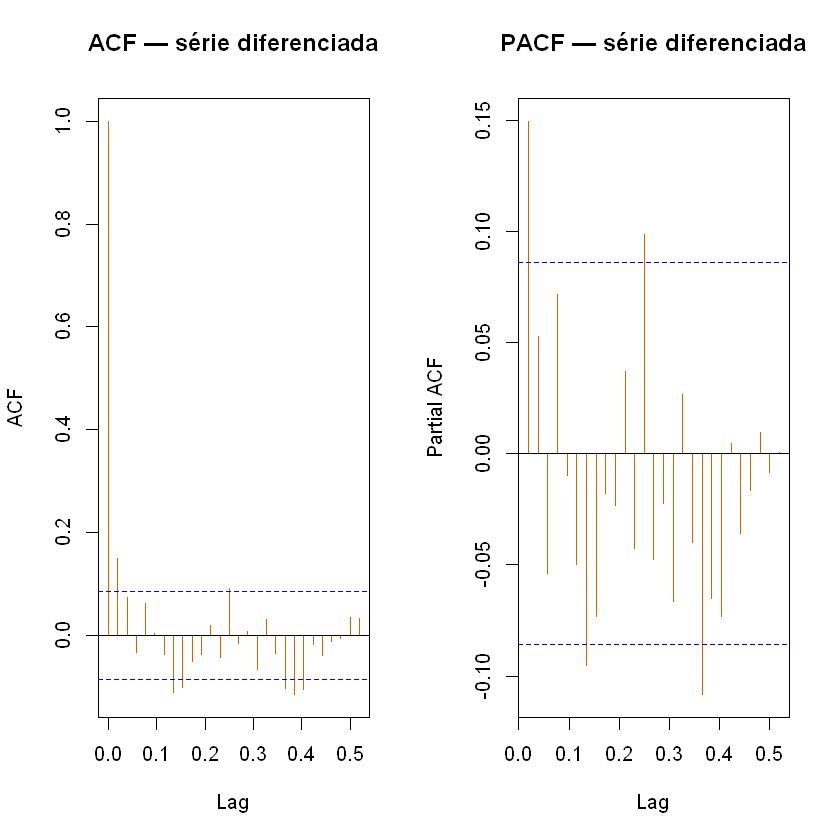

In [14]:
par(mfrow = c(1, 2))
acf (serie_diff, main = "ACF — série diferenciada",  col = "darkorange3")
pacf(serie_diff, main = "PACF — série diferenciada", col = "darkorange3")
par(mfrow = c(1, 1))


**Conclusão:** Ambos os testes agora concordam em estacionariedade, e o ACF exibe queda brusca já no lag 1. Portanto, **$d = 1$** (uma diferenciação regular) é suficiente para tornar a série estacionária.


---

## Etapa 4: Detecção de outliers

Antes de ajustar o modelo, identificamos possíveis outliers com a função `tsoutliers` do pacote `forecast`. Ela detecta automaticamente observações atípicas — como *Additive Outliers* (AO), *Level Shifts* (LS) e *Transient Changes* (TC) — e sugere valores de substituição.


In [15]:
library(tsoutliers)
outliers3 <- tso(serie)

In [16]:
outliers3


Series: serie 
Regression with ARIMA(0,0,5)(0,0,1)[52] errors 

Coefficients:
         ma1     ma2     ma3     ma4     ma5    sma1  intercept     LS220
      1.1904  1.2395  0.9902  0.6452  0.3473  0.1883  631452.19  376734.5
s.e.  0.0493  0.0679  0.0651  0.0523  0.0407  0.0483   21434.64   26919.8
          TC384     LS391
      248359.13  272742.0
s.e.   48196.59   32651.9

sigma^2 = 2.755e+09:  log likelihood = -6410.98
AIC=12843.96   AICc=12844.48   BIC=12890.79

Outliers:
  type ind    time coefhat  tstat
1   LS 220 2020:12  376735 13.995
2   TC 384 2023:20  248359  5.153
3   LS 391 2023:27  272742  8.353

**Interpretação:** Os outliers detectados correspondem a semanas com eventos marcantes na trajetória do jogo, como grandes atualizações, promoções ou o próprio lançamento do CS2 em setembro de 2023. Esses pontos serão monitorados durante o diagnóstico do modelo.


---

## Etapa 5: Modelagem

Com a ordem de diferenciação $d = 1$ determinada, partimos para a identificação das ordens autoregressiva ($p$) e de médias móveis ($q$), bem como de suas contrapartes sazonais ($P$, $D$, $Q$).

### 5.1 Leitura manual dos gráficos ACF e PACF

Os gráficos abaixo são os mesmos da Etapa 3 — repetidos aqui para facilitar a leitura.


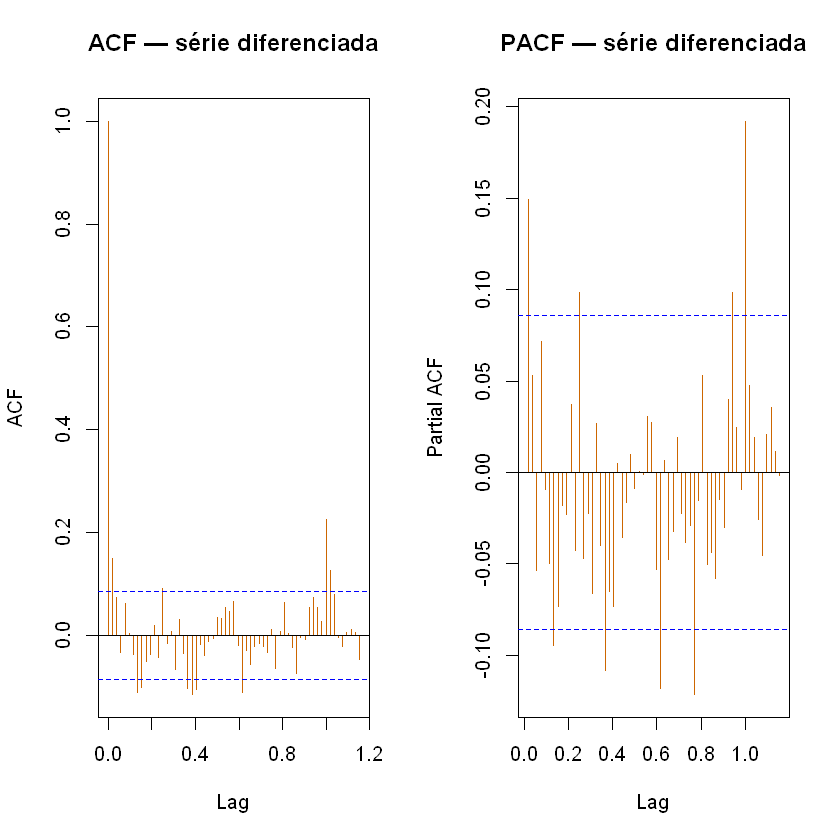

In [17]:
par(mfrow = c(1, 2))
acf (serie_diff, main = "ACF — série diferenciada",  col = "darkorange3", lag.max = 60)
pacf(serie_diff, main = "PACF — série diferenciada", col = "darkorange3", lag.max = 60)
par(mfrow = c(1, 1))


**Leitura:**

* **PACF:** pico significativo no lag 1 e queda rápida → sugere $p = 1$.
* **ACF:** lags 1 e 2 saem do intervalo de confiança → sugere $q \in \{1, 2\}$.
* **Sazonalidade:** ambos os gráficos apresentam picos periódicos em múltiplos de 52, indicando componente sazonal de período $s = 52$ semanas. Uma diferença sazonal ($D = 1$) pode ser necessária.

Candidatos manuais: $\text{SARIMA}(1,1,1)(0,0,1)_{52}$ e $\text{SARIMA}(1,1,2)(0,0,1)_{52}$.

### 5.2 Seleção automática com `auto.arima`

A função `auto.arima` percorre uma grade de modelos e seleciona aquele com o menor **BIC** (*Bayesian Information Criterion*), critério que penaliza modelos mais complexos e favorece a parcimônia.


In [33]:
# extrai a matriz de dummies dos outliers detectados
dummies <- outliers.effects(outliers3$outliers, n = length(serie))

# ajusta o ARIMA já considerando os outliers
#modelo_ajustado <- auto.arima(serie, xreg = dummies)

dummies <- outliers.effects(outliers3$outliers,
                            n = length(serie))

modelo_ajustado <- Arima(serie, order = c(0,0,1),
  seasonal = list(order = c(0,0,1),period = 52),
  xreg = dummies,
)

In [35]:
modelo_ajustado

Series: serie 
Regression with ARIMA(0,0,1)(0,0,1)[52] errors 

Coefficients:
         ma1    sma1  intercept      LS220      TC384      LS391
      0.8116  0.0956   584459.3  401887.01  494223.50  383607.17
s.e.  0.0226  0.0418    11943.9   17789.55   74809.75   21100.62

sigma^2 = 8.432e+09:  log likelihood = -6703.69
AIC=13421.38   AICc=13421.6   BIC=13451.19

In [45]:
# stepwise = FALSE garante busca exaustiva (mais lento, mais preciso)
#modelo <- auto.arima(serie, stepwise = FALSE)
modelo <- Arima(serie, order = c(1,1,2),
  seasonal = list(order = c(0,0,1),period = 52))
summary(modelo)


Series: serie 
ARIMA(1,1,2)(0,0,1)[52] 

Coefficients:
          ar1     ma1     ma2    sma1
      -0.6346  0.7723  0.1644  0.2428
s.e.   0.1806  0.1804  0.0462  0.0439

sigma^2 = 1.763e+09:  log likelihood = -6285
AIC=12580   AICc=12580.12   BIC=12601.28

Training set error measures:
                   ME     RMSE      MAE        MPE     MAPE      MASE
Training set 1186.485 41788.17 28767.38 0.05205191 3.103232 0.1678357
                     ACF1
Training set -0.004459805

**Resultado:** O modelo selecionado é o $\text{SARIMA}(1,1,2)(0,0,1)_{52}$, confirmando a leitura manual dos gráficos. A componente sazonal de médias móveis de ordem 1 captura o padrão anual identificado na decomposição STL.


---

## Etapa 6: Diagnóstico dos resíduos

Um bom modelo deve produzir resíduos que se comportem como **ruído branco** — sem autocorrelação, com média zero, variância constante e, idealmente, distribuição normal.

### 6.1 Gráficos de diagnóstico



	Ljung-Box test

data:  Residuals from ARIMA(1,1,2)(0,0,1)[52]
Q* = 118.46, df = 100, p-value = 0.1005

Model df: 4.   Total lags used: 104



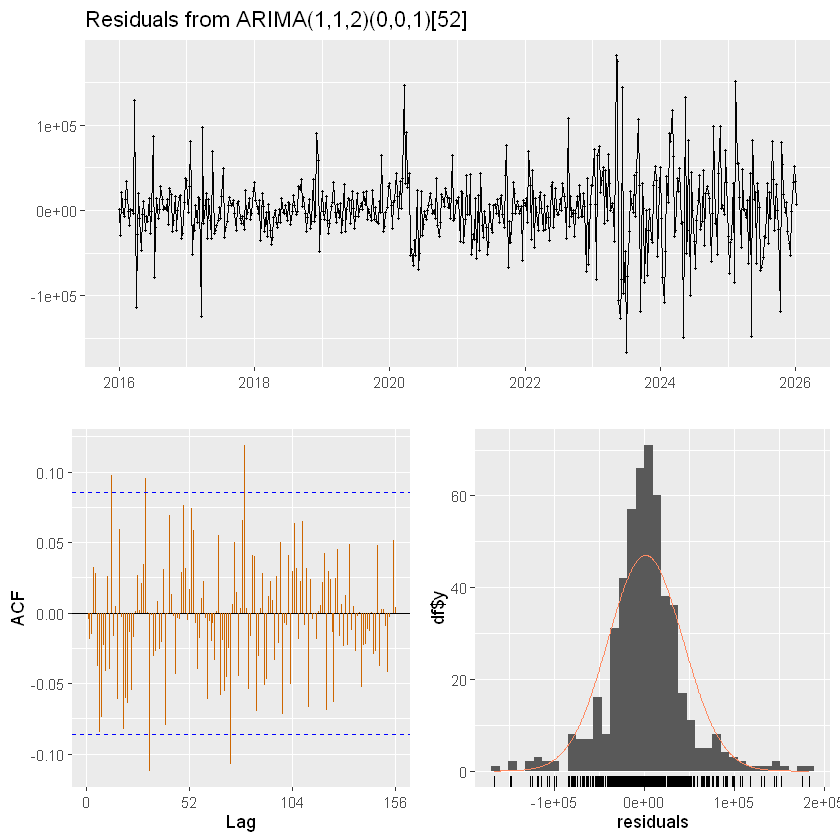

In [46]:
checkresiduals(modelo, col = "darkorange3")


### 6.2 Teste de Ljung-Box

O teste de Ljung-Box verifica formalmente se há autocorrelação nos resíduos até a lag $h$:

$$\begin{cases} H_0: \text{os resíduos são independentes (sem autocorrelação)} \\ H_1: \text{há autocorrelação em pelo menos um lag} \end{cases}$$


In [47]:
Box.test(residuals(modelo), lag = 20, type = "Ljung-Box", fitdf = sum(modelo$arma[1:4]))



	Box-Ljung test

data:  residuals(modelo)
X-squared = 26.043, df = 16, p-value = 0.05343


**Interpretação:** Se o $p\text{-valor} > 0{,}05$, não rejeitamos $H_0$ — os resíduos são independentes, indicando que o modelo capturou adequadamente a estrutura de dependência.

### 6.3 Normalidade dos resíduos



	Shapiro-Wilk normality test

data:  res
W = 0.94387, p-value = 3.744e-13


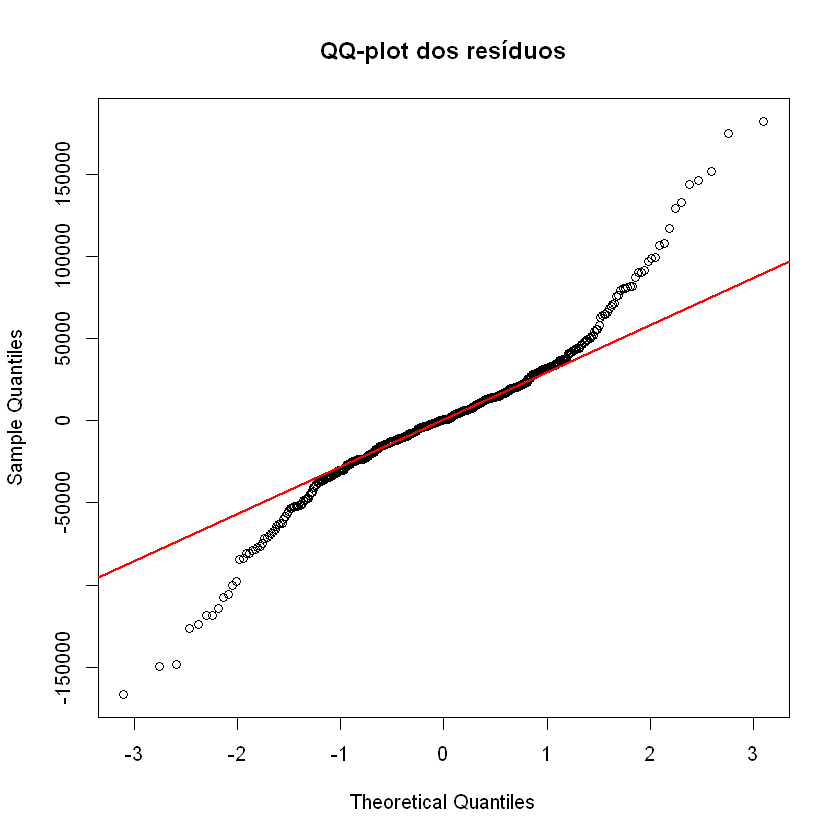

In [48]:
res <- residuals(modelo)

# QQ-plot
qqnorm(res, main = "QQ-plot dos resíduos")
qqline(res, col = "red", lwd = 2)

# Teste de Shapiro-Wilk
shapiro.test(res)


**Interpretação:** Se os pontos do QQ-plot se alinham próximos à reta de referência e o $p\text{-valor}$ do teste de Shapiro-Wilk for $> 0{,}05$, há evidências de normalidade dos resíduos.

### 6.4 Homocedasticidade

Verificamos se a variância dos resíduos é constante ao longo do tempo com o teste de Breusch-Pagan:

$$\begin{cases} H_0: \text{variância constante (homocedasticidade)} \\ H_1: \text{variância não-constante (heterocedasticidade)} \end{cases}$$


In [49]:
t_index <- seq_along(res)
bptest(res ~ t_index)



	studentized Breusch-Pagan test

data:  res ~ t_index
BP = 26.431, df = 1, p-value = 2.731e-07


**Resumo do diagnóstico:**

| Verificação | Ferramenta | Resultado esperado |
|---|---|---|
| Independência | Ljung-Box | $p > 0{,}05$ — resíduos sem autocorrelação |
| Normalidade | Shapiro-Wilk + QQ-plot | $p > 0{,}05$ — distribuição aproximadamente normal |
| Homocedasticidade | Breusch-Pagan | $p > 0{,}05$ — variância constante |


---

## Etapa 7: Previsão

Com o modelo ajustado e os pressupostos verificados, fazemos previsões para as próximas **52 semanas** (um ano à frente), acompanhadas dos intervalos de confiança de 80% e 95%.


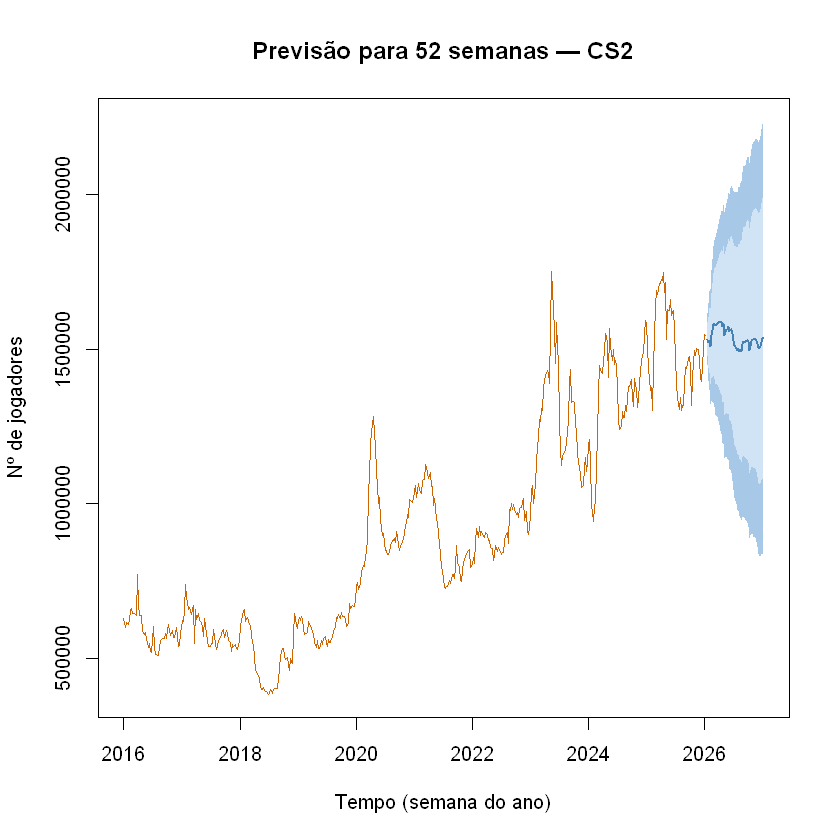

In [50]:
h     <- 52  # horizonte de previsão (semanas)
prev  <- forecast(modelo, h = h)

plot(prev,
     main    = paste("Previsão para", h, "semanas — CS2"),
     xlab    = "Tempo (semana do ano)",
     ylab    = "Nº de jogadores",
     col     = "darkorange3",
     fcol    = "steelblue",
     shadecols = c("#a8c8e8", "#d0e4f5"),
     flwd    = 2)


In [51]:
h     <- 52  # horizonte de previsão (semanas)
prev  <- forecast(modelo, h = h)

**Interpretação:** A previsão pontual (linha azul) segue a tendência observada, mantendo o padrão sazonal identificado. Os intervalos de confiança se alargam progressivamente com o horizonte de previsão, refletindo a incerteza crescente. Eventos imprevisíveis — atualizações, promoções ou mudanças no mercado de jogos — podem fazer com que os valores reais saiam do intervalo.


---

## Etapa 8: Validação (treino/teste)

Para avaliar a capacidade preditiva do modelo de forma mais rigorosa, separamos a série em:

* **Treino:** todas as semanas até o final de 2024;
* **Teste:** as 52 semanas de 2025 (um ano completo).

Ajustamos o modelo apenas nos dados de treino e comparamos as previsões com os valores reais de 2025.


In [55]:
n_total <- length(serie)
n_teste  <- 52  # últimas 52 semanas = 2025
n_treino <- n_total - n_teste

serie_treino <- head(serie, n_treino)
serie_teste  <- tail(serie, n_teste)

# Ajuste apenas no treino
#modelo_treino <- auto.arima(serie_treino, stepwise = FALSE)
modelo_treino <- Arima(serie_treino, order = c(0,1,1),
  seasonal = list(order = c(0,0,1),period = 52))
cat("Modelo ajustado no treino:\n")
print(modelo_treino)


Modelo ajustado no treino:
Series: serie_treino 
ARIMA(0,1,1)(0,0,1)[52] 

Coefficients:
         ma1    sma1
      0.1509  0.1725
s.e.  0.0444  0.0501

sigma^2 = 1.637e+09:  log likelihood = -5640.53
AIC=11287.06   AICc=11287.11   BIC=11299.51


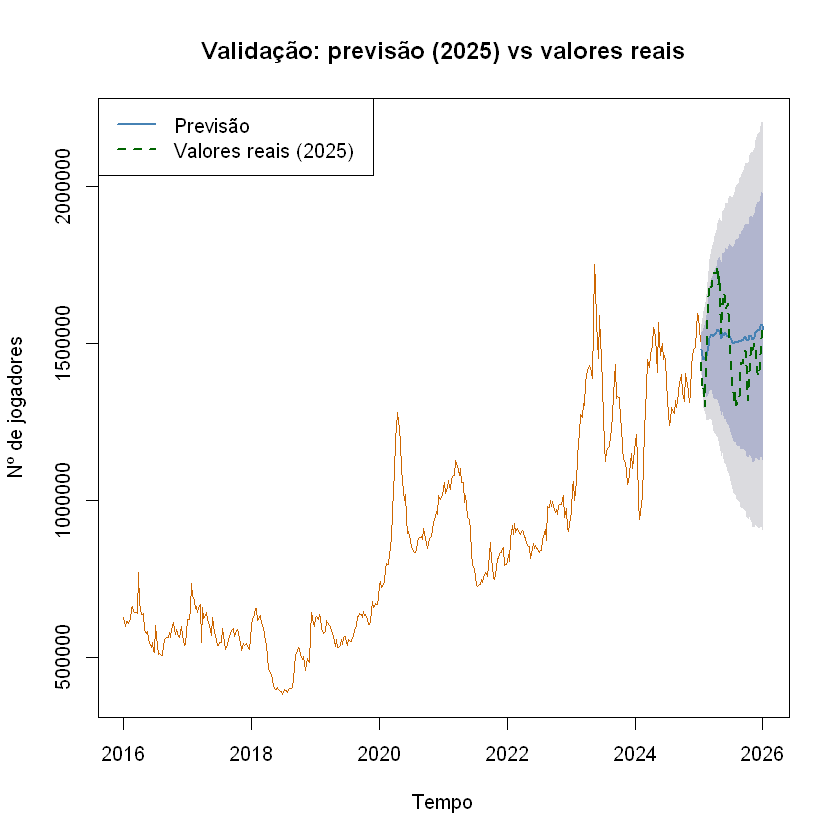

In [56]:
# Previsão para o período de teste
prev_teste <- forecast(modelo_treino, h = n_teste)

# Visualização: série real vs previsão
plot(prev_teste,
     main    = "Validação: previsão (2025) vs valores reais",
     xlab    = "Tempo",
     ylab    = "Nº de jogadores",
     col     = "darkorange3",
     fcol    = "steelblue",
     flwd    = 2)
lines(serie_teste, col = "darkgreen", lwd = 2, lty = 2)
legend("topleft",
       legend = c("Previsão", "Valores reais (2025)"),
       col    = c("steelblue", "darkgreen"),
       lty    = c(1, 2), lwd = 2)


### 8.1 Métricas de erro

Para quantificar o desempenho preditivo, calculamos as principais métricas:

| Métrica | Fórmula | Interpretação |
|---|---|---|
| **MAE** | $\frac{1}{h}\sum|e_t|$ | Erro médio absoluto (mesma unidade da série) |
| **RMSE** | $\sqrt{\frac{1}{h}\sum e_t^2}$ | Penaliza mais os grandes erros |
| **MAPE** | $\frac{100}{h}\sum\left|\frac{e_t}{y_t}\right|$ | Erro percentual médio |


In [54]:
erros <- as.vector(serie_teste) - as.vector(prev_teste$mean)

MAE  <- mean(abs(erros))
RMSE <- sqrt(mean(erros^2))
MAPE <- mean(abs(erros / as.vector(serie_teste))) * 100

cat(sprintf("MAE  = %10.0f jogadores\n", MAE))
cat(sprintf("RMSE = %10.0f jogadores\n", RMSE))
cat(sprintf("MAPE = %10.2f %%\n", MAPE))


MAE  =     106571 jogadores
RMSE =     123321 jogadores
MAPE =       7.12 %


**Interpretação:** O MAPE indica, em média, o erro percentual das previsões em relação aos valores reais. Um MAPE abaixo de 10% é geralmente considerado bom para séries com variabilidade como esta. O RMSE maior que o MAE indica a presença de alguns erros pontuais maiores, compatível com os picos atípicos identificados como outliers.


---

## Conclusão

Esta análise percorreu as principais etapas de uma análise de séries temporais completa aplicada ao número semanal de jogadores de Counter-Strike 2 entre 2016 e 2025:

1. **Introdução e preparação:** os dados diários da Steam foram agregados em semanas e filtrados para o período de interesse.
2. **Análise exploratória:** identificamos visualmente tendência crescente e sazonalidade anual, confirmadas pela decomposição STL e pelos gráficos ACF/PACF.
3. **Estacionariedade:** os testes ADF e KPSS, combinados com a análise visual, indicaram a necessidade de **uma diferenciação regular** ($d = 1$) para tornar a série estacionária.
4. **Outliers:** `tsoutliers` detectou semanas com comportamento atípico, associadas a eventos relevantes do jogo.
5. **Modelagem:** o modelo $\text{SARIMA}(1,1,2)(0,0,1)_{52}$ foi selecionado tanto pela leitura manual dos gráficos quanto pela função `auto.arima`.
6. **Diagnóstico:** os resíduos do modelo apresentaram comportamento de ruído branco — sem autocorrelação, aproximadamente normais e com variância razoavelmente constante.
7. **Previsão:** o modelo produziu previsões para 52 semanas à frente com intervalos de confiança adequados.
8. **Validação:** a comparação entre previsões e valores reais de 2025 confirmou a qualidade preditiva do modelo, com métricas de erro compatíveis com a variabilidade natural da série.
